# 06 — Ensemble (CatBoost + LightGBM) for 3‑hour Collision Risk (y_class)

**Goal:** predict collision risk in the **next 3 hours** for each HOOD/time block using your engineered features (weather, hour/time, lags, etc.).

**Target (`y_class`) definition**
- `0` → 0 collisions
- `1` → exactly 1 collision
- `2` → 2 or more collisions

This notebook is a **continuation** of `05_best_ml_catboost_lightgbm.ipynb` and builds **ensembles** from the same two base models:
1) **Soft-voting average**  
2) **Weighted soft-voting** (weight tuned on validation)  
3) **Stacking** (meta‑learner over base model probabilities)

It also keeps your **high‑risk threshold tuning** idea (tuning `tau` for class 2 recall/precision tradeoff).


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report, recall_score, precision_score
import joblib

# ----------------------------
# Paths (same layout as notebook 05)
# ----------------------------
BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data" / "processed"
MODEL_DIR = BASE_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

SUPERVISED_PATH = DATA_DIR / "supervised_hood_3h_multiclass.csv"

# Base-model artifacts produced by notebook 05
CB_MODEL_PATH   = MODEL_DIR / "best_ml_catboost.cbm"
CB_TAU_PATH     = MODEL_DIR / "best_ml_catboost_tau.txt"
LGBM_MODEL_PATH = MODEL_DIR / "best_ml_lightgbm.joblib"
LGBM_TAU_PATH   = MODEL_DIR / "best_ml_lightgbm_tau.txt"

# Ensemble outputs (this notebook)
ENS_CONFIG_PATH = MODEL_DIR / "ensemble_cb_lgbm_config.json"
ENS_META_PATH   = MODEL_DIR / "ensemble_cb_lgbm_meta.joblib"

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


In [2]:
# ----------------------------
# Load supervised dataset (3-hour horizon)
# ----------------------------
df = pd.read_csv(SUPERVISED_PATH, low_memory=False)

# Expected columns from your pipeline
df["time_3h"] = pd.to_datetime(df["time_3h"], errors="coerce")
df["HOOD_158_CODE"] = df["HOOD_158_CODE"].astype(str).str.zfill(3)

df["y_class"] = pd.to_numeric(df["y_class"], errors="coerce").astype("int8")
df = df.sort_values(["time_3h", "HOOD_158_CODE"]).reset_index(drop=True)

print("Shape:", df.shape)
print("Class distribution:")
print(df["y_class"].value_counts(normalize=True).sort_index().round(4))


Shape: (1383922, 50)
Class distribution:
y_class
0    0.8930
1    0.0927
2    0.0143
Name: proportion, dtype: float64


In [3]:
# ----------------------------
# Time-based split (same cutoffs as notebook 05)
# Train: up to 2024-12-31
# Val:   2025-01-01 to 2025-06-30
# Test:  2025-07-01 onward
# ----------------------------
t = df["time_3h"]
train_end = pd.Timestamp("2024-12-31 23:59:59")
val_end   = pd.Timestamp("2025-06-30 23:59:59")

train_mask = t <= train_end
val_mask   = (t > train_end) & (t <= val_end)
test_mask  = t > val_end

y = df["y_class"].copy()

# Remove target + any leakage columns
X = df.drop(columns=[c for c in ["y_class", "y_count_next"] if c in df.columns], errors="ignore").copy()

# Do not use the raw timestamp as a feature (keep engineered time features instead)
X = X.drop(columns=["time_3h"], errors="ignore")

X_train, y_train = X.loc[train_mask].copy(), y.loc[train_mask].copy()
X_val, y_val     = X.loc[val_mask].copy(), y.loc[val_mask].copy()
X_test, y_test   = X.loc[test_mask].copy(), y.loc[test_mask].copy()

print("Train/Val/Test:", X_train.shape, X_val.shape, X_test.shape)


Train/Val/Test: (922720, 47) (228784, 47) (232418, 47)


In [4]:
# ----------------------------
# Feature selection (optional)
# If you used 'top25' in notebook 05, you can reuse it here.
# ----------------------------
SEL_FEATURES_PATH = DATA_DIR / "logreg_selected_top25_features.txt"
use_selected_features = False  # set True to use the saved feature list

if use_selected_features and SEL_FEATURES_PATH.exists():
    with open(SEL_FEATURES_PATH, "r") as f:
        sel = [line.strip() for line in f if line.strip()]
    sel = [c for c in sel if c in X_train.columns]
    if "HOOD_158_CODE" in X_train.columns and "HOOD_158_CODE" not in sel:
        sel.append("HOOD_158_CODE")
    X_train = X_train[sel].copy()
    X_val   = X_val[sel].copy()
    X_test  = X_test[sel].copy()
    print("Using selected features:", len(sel))
else:
    sel = list(X_train.columns)
    print("Using all features:", len(sel))

# Identify categorical vs numeric (same logic as notebook 05)
cat_cols = [c for c in X_train.columns if X_train[c].dtype == "object"]
if "HOOD_158_CODE" in X_train.columns and "HOOD_158_CODE" not in cat_cols:
    cat_cols.append("HOOD_158_CODE")
num_cols = [c for c in X_train.columns if c not in cat_cols]

print("Categorical:", cat_cols)
print("Numeric count:", len(num_cols))


Using all features: 47
Categorical: ['HOOD_158_CODE']
Numeric count: 46


In [5]:
# ----------------------------
# Evaluation helpers (copied from notebook 05)
# ----------------------------
def plot_confusion(cm, labels=(0,1,2), title="Confusion Matrix"):
    fig, ax = plt.subplots()
    ax.imshow(cm)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")
    plt.show()

def eval_multiclass(y_true, y_pred, name="Model"):
    cm = confusion_matrix(y_true, y_pred, labels=[0,1,2])
    rec = recall_score(y_true, y_pred, labels=[0,1,2], average=None, zero_division=0)
    macro_rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
    rec_high = recall_score((y_true==2).astype(int), (y_pred==2).astype(int), zero_division=0)
    prec_high = precision_score((y_true==2).astype(int), (y_pred==2).astype(int), zero_division=0)

    print(f"\n=== {name} ===")
    print("Per-class recall [0,1,2]:", np.round(rec, 4))
    print("Macro recall:", round(float(macro_rec), 4))
    print("High-risk recall:", round(float(rec_high), 4))
    print("High-risk precision:", round(float(prec_high), 4))
    print("\n", classification_report(y_true, y_pred, digits=4, zero_division=0))
    plot_confusion(cm, title=f"{name} Confusion Matrix")
    return {
        "recall_0": float(rec[0]), "recall_1": float(rec[1]), "recall_2": float(rec[2]),
        "macro_recall": float(macro_rec), "recall_high": float(rec_high), "precision_high": float(prec_high)
    }

def apply_highrisk_threshold(proba, tau, class2_index=2):
    """If P(class2)>=tau predict 2 else argmax among {0,1}."""
    p2 = proba[:, class2_index]
    pred01 = np.argmax(proba[:, [0,1]], axis=1)
    preds = pred01.copy()
    preds[p2 >= tau] = 2
    return preds

def choose_tau_by_constraint(proba, y_true, target_recall_high=0.80):
    taus = np.linspace(0.05, 0.95, 19)
    rows = []
    for tau in taus:
        pred = apply_highrisk_threshold(proba, tau, class2_index=2)
        rec_high = recall_score((y_true==2).astype(int), (pred==2).astype(int), zero_division=0)
        prec_high = precision_score((y_true==2).astype(int), (pred==2).astype(int), zero_division=0)
        macro_rec = recall_score(y_true, pred, average="macro", zero_division=0)
        rows.append((tau, rec_high, prec_high, macro_rec))
    tau_df = pd.DataFrame(rows, columns=["tau","recall_high","precision_high","macro_recall"]).sort_values("tau")
    candidates = tau_df[tau_df["recall_high"] >= target_recall_high].copy()
    if len(candidates) == 0:
        chosen = tau_df.sort_values(["macro_recall","recall_high"], ascending=False).iloc[0]
    else:
        chosen = candidates.sort_values(["macro_recall","precision_high"], ascending=False).iloc[0]
    return float(chosen["tau"]), tau_df

def apply_two_thresholds(proba, tau1, tau2):
    p1 = proba[:, 1]
    p2 = proba[:, 2]
    pred = np.zeros(len(p1), dtype=int)
    pred[p1 >= tau1] = 1
    pred[p2 >= tau2] = 2
    return pred

def tune_two_thresholds(proba_val, y_val,
                        tau1_grid=np.linspace(0.20, 0.70, 11),
                        tau2_grid=np.linspace(0.05, 0.40, 15),
                        min_recall_1=0.25,
                        max_pred2_rate=0.15):
    rows = []
    for tau1 in tau1_grid:
        for tau2 in tau2_grid:
            pred = apply_two_thresholds(proba_val, tau1, tau2)
            rec = recall_score(y_val, pred, labels=[0,1,2], average=None, zero_division=0)
            macro = recall_score(y_val, pred, average="macro", zero_division=0)
            rec_high = recall_score((y_val==2).astype(int), (pred==2).astype(int), zero_division=0)
            prec_high = precision_score((y_val==2).astype(int), (pred==2).astype(int), zero_division=0)
            pred2_rate = float((pred==2).mean())
            rows.append((tau1, tau2, macro, rec[1], rec_high, prec_high, pred2_rate))
    df = pd.DataFrame(rows, columns=["tau1","tau2","macro_recall","recall_1","recall_2","precision_2","pred2_rate"])
    feasible = df[(df["recall_1"] >= min_recall_1) & (df["pred2_rate"] <= max_pred2_rate)]
    best = (feasible if len(feasible) else df).sort_values(
        ["macro_recall","recall_2","precision_2"], ascending=False
    ).iloc[0]
    return float(best["tau1"]), float(best["tau2"]), df

def soft_vote_per_class(p_cb, p_lg, w_by_class=(0.5, 0.3, 0.7)):
    """
    w_by_class: (w0, w1, w2) = CatBoost weights per class.
    Example: w1 low -> trust LGBM more for class 1, w2 high -> trust CB more for class 2
    """
    w = np.array(w_by_class, dtype=float).reshape(1, 3)
    p = w * p_cb + (1.0 - w) * p_lg
    p = p / p.sum(axis=1, keepdims=True)
    return p

In [6]:
# ----------------------------
# Class weights (balanced) — helps rare class 2
# ----------------------------
class_counts = y_train.value_counts().sort_index()
total = class_counts.sum()
weights = (total / (3 * class_counts)).to_dict()

print("Class counts (train):")
print(class_counts)
print("Class weights:")
print(weights)


Class counts (train):
y_class
0    823183
1     86350
2     13187
Name: count, dtype: int64
Class weights:
{0: 0.373639073369267, 1: 3.561937849835939, 2: 23.323980688051364}


## 1) Load (or train) the two base models

If you already ran notebook 05, the models should exist under `../models/`.
This notebook will **load** them if found; otherwise it will **train** them with the same settings.


In [7]:
# ----------------------------
# CatBoost: load or train
# ----------------------------
cb = None
cb_available = False
try:
    from catboost import CatBoostClassifier
    cb_available = True
except Exception as e:
    print("CatBoost not available:", e)

if cb_available:
    if CB_MODEL_PATH.exists():
        cb = CatBoostClassifier()
        cb.load_model(str(CB_MODEL_PATH))
        print("Loaded CatBoost:", CB_MODEL_PATH)
    else:
        # Train with the same settings as notebook 05
        cat_features = [X_train.columns.get_loc(c) for c in cat_cols]  # indices
        cb = CatBoostClassifier(
            loss_function="MultiClass",
            eval_metric="MultiClass",
            iterations=2000,
            learning_rate=0.05,
            depth=8,
            l2_leaf_reg=3.0,
            random_seed=RANDOM_SEED,
            verbose=200,
            class_weights=[weights.get(0,1.0), weights.get(1,1.0), weights.get(2,1.0)],
            od_type="Iter",
            od_wait=200
        )
        cb.fit(
            X_train, y_train,
            cat_features=cat_features,
            eval_set=(X_val, y_val),
            use_best_model=True
        )
        cb.save_model(str(CB_MODEL_PATH))
        print("Trained + saved CatBoost:", CB_MODEL_PATH)

# ----------------------------
# LightGBM: load or train (pipeline with preprocessing)
# ----------------------------
lgbm_pipe = None
lgbm_available = False
try:
    from lightgbm import LGBMClassifier
    lgbm_available = True
except Exception as e:
    print("LightGBM not available:", e)

if lgbm_available:
    if LGBM_MODEL_PATH.exists():
        lgbm_pipe = joblib.load(LGBM_MODEL_PATH)
        print("Loaded LightGBM pipeline:", LGBM_MODEL_PATH)
    else:
        from sklearn.compose import ColumnTransformer
        from sklearn.pipeline import Pipeline
        from sklearn.preprocessing import OneHotEncoder
        from sklearn.impute import SimpleImputer

        numeric_transformer = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
        ])

        categorical_transformer = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ])

        preprocess_lgbm = ColumnTransformer(
            transformers=[
                ("num", numeric_transformer, num_cols),
                ("cat", categorical_transformer, cat_cols),
            ],
            remainder="drop"
        )

        lgbm = LGBMClassifier(
            objective="multiclass",
            num_class=3,
            n_estimators=2000,
            learning_rate=0.05,
            num_leaves=63,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=RANDOM_SEED,
            class_weight=weights,
            n_jobs=-1
        )

        lgbm_pipe = Pipeline(steps=[
            ("preprocess", preprocess_lgbm),
            ("model", lgbm)
        ])

        lgbm_pipe.fit(X_train, y_train)
        joblib.dump(lgbm_pipe, LGBM_MODEL_PATH)
        print("Trained + saved LightGBM pipeline:", LGBM_MODEL_PATH)

# Safety check
if cb is None or lgbm_pipe is None:
    raise RuntimeError("Both base models must be available. Install `catboost` and `lightgbm` then rerun.")


Loaded CatBoost: ../models/best_ml_catboost.cbm
Loaded LightGBM pipeline: ../models/best_ml_lightgbm.joblib


In [8]:
# ----------------------------
# Base model probabilities
# ----------------------------
proba_train_cb  = cb.predict_proba(X_train)
proba_val_cb    = cb.predict_proba(X_val)
proba_test_cb   = cb.predict_proba(X_test)

proba_train_lgbm = lgbm_pipe.predict_proba(X_train)
proba_val_lgbm   = lgbm_pipe.predict_proba(X_val)
proba_test_lgbm  = lgbm_pipe.predict_proba(X_test)

print("Shapes (val):", proba_val_cb.shape, proba_val_lgbm.shape)


Shapes (val): (228784, 3) (228784, 3)


## 2) Ensemble A — Simple soft‑voting (average probabilities)

This is the most stable ensemble baseline:  
\[
P_{ens} = \frac{P_{CatBoost} + P_{LightGBM}}{2}
\]



=== Ensemble AVG Argmax - Val ===
Per-class recall [0,1,2]: [0.8777 0.3021 0.2127]
Macro recall: 0.4641
High-risk recall: 0.2127
High-risk precision: 0.127

               precision    recall  f1-score   support

           0     0.9275    0.8777    0.9019    204791
           1     0.2120    0.3021    0.2491     20758
           2     0.1270    0.2127    0.1590      3235

    accuracy                         0.8160    228784
   macro avg     0.4221    0.4641    0.4367    228784
weighted avg     0.8513    0.8160    0.8322    228784



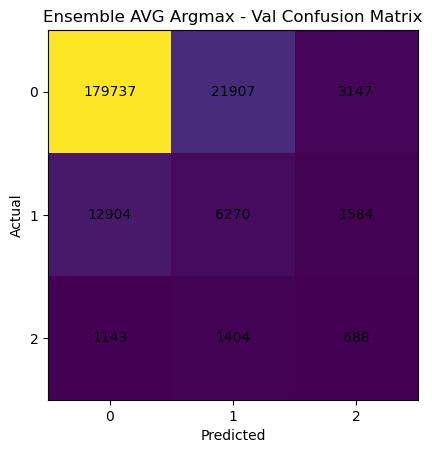


=== Ensemble AVG Argmax - Test ===
Per-class recall [0,1,2]: [0.8621 0.3209 0.2779]
Macro recall: 0.487
High-risk recall: 0.2779
High-risk precision: 0.1298

               precision    recall  f1-score   support

           0     0.9309    0.8621    0.8952    207818
           1     0.2082    0.3209    0.2525     21189
           2     0.1298    0.2779    0.1769      3411

    accuracy                         0.8042    232418
   macro avg     0.4230    0.4870    0.4416    232418
weighted avg     0.8533    0.8042    0.8261    232418



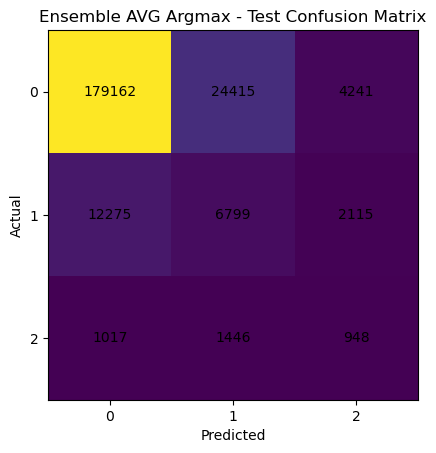

Chosen thresholds (AVG): {'tau1': 0.3, 'tau2': 0.175}


,tau1,tau2,macro_recall,recall_1,recall_2,precision_2,pred2_rate
35,0.30,0.175,0.538394,0.426823,0.590108,0.063570,0.131259
34,0.30,0.150,0.537833,0.376915,0.640185,0.056322,0.160724
36,0.30,0.200,0.536289,0.472203,0.537249,0.070507,0.107744
50,0.35,0.175,0.535471,0.308700,0.590108,0.063570,0.131259
33,0.30,0.125,0.535464,0.316215,0.697063,0.049517,0.199052
49,0.35,0.150,0.535375,0.264284,0.640185,0.056322,0.160724
48,0.35,0.125,0.534217,0.212978,0.697063,0.049517,0.199052
51,0.35,0.200,0.532702,0.349263,0.537249,0.070507,0.107744
37,0.30,0.225,0.531330,0.510020,0.483771,0.077052,0.088778
20,0.25,0.175,0.530949,0.514211,0.590108,0.063570,0.131259



=== Ensemble AVG Two-Threshold (tau1=0.30, tau2=0.17) - Test ===
Per-class recall [0,1,2]: [0.5727 0.4024 0.6529]
Macro recall: 0.5427
High-risk recall: 0.6529
High-risk precision: 0.0638

               precision    recall  f1-score   support

           0     0.9602    0.5727    0.7175    207818
           1     0.1159    0.4024    0.1800     21189
           2     0.0638    0.6529    0.1162      3411

    accuracy                         0.5584    232418
   macro avg     0.3800    0.5427    0.3379    232418
weighted avg     0.8701    0.5584    0.6597    232418



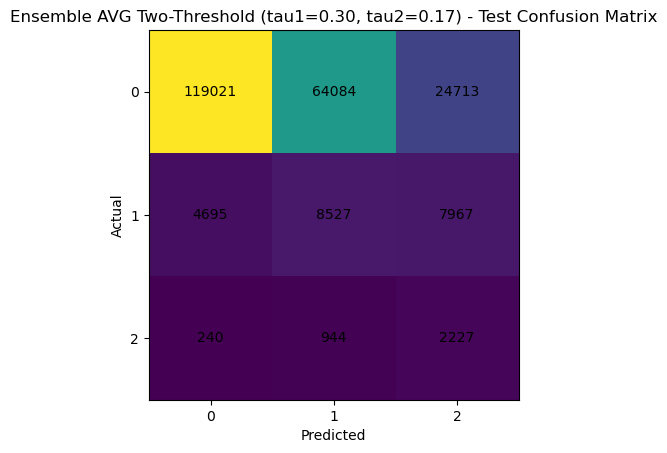

In [10]:
def soft_vote(proba_a, proba_b, w=0.5):
    # w = weight for model A, (1-w) for model B
    return w * proba_a + (1.0 - w) * proba_b

# --- Validation ---
proba_val_avg = soft_vote(proba_val_cb, proba_val_lgbm, w=0.5)
pred_val_avg = np.argmax(proba_val_avg, axis=1)
metrics_val_avg = eval_multiclass(y_val, pred_val_avg, name="Ensemble AVG Argmax - Val")

# --- Test ---
proba_test_avg = soft_vote(proba_test_cb, proba_test_lgbm, w=0.5)
pred_test_avg = np.argmax(proba_test_avg, axis=1)
metrics_test_avg = eval_multiclass(y_test, pred_test_avg, name="Ensemble AVG Argmax - Test")

# --- High-risk threshold tuning on validation, applied to test ---
tau1_avg, tau2_avg, grid_avg = tune_two_thresholds(proba_val_avg, y_val, min_recall_1=0.25, max_pred2_rate=0.15)
print("Chosen thresholds (AVG):", {"tau1": tau1_avg, "tau2": tau2_avg})
display(grid_avg.sort_values(["macro_recall","recall_2","precision_2"], ascending=False).head(10))

pred_test_avg_thr = apply_two_thresholds(proba_test_avg, tau1_avg, tau2_avg)
metrics_test_avg_thr = eval_multiclass(y_test, pred_test_avg_thr, name=f"Ensemble AVG Two-Threshold (tau1={tau1_avg:.2f}, tau2={tau2_avg:.2f}) - Test")



## 3) Ensemble B — Weighted soft‑voting (weight tuned on validation)

We tune the mixing weight \(w\) on **validation** to improve minority-class recall, macro‑recall, or high‑risk recall.


In [11]:
# ----------------------------
# Tune weight 'w' on validation
# - w = weight for CatBoost
# - (1-w) = weight for LightGBM
# Criterion: maximize macro_recall, with an optional minimum recall_high constraint
# ----------------------------
def tune_per_class_weights(proba_val_cb, proba_val_lgbm, y_val,
                           w0=0.5,
                           w1_grid=np.linspace(0.0, 0.6, 7),   # let LGBM dominate class1
                           w2_grid=np.linspace(0.4, 1.0, 7),   # let CB dominate class2
                           min_recall_1=0.25,
                           max_pred2_rate=0.15):
    rows=[]
    best=None
    best_score=-1e9

    for w1 in w1_grid:
        for w2 in w2_grid:
            p = soft_vote_per_class(proba_val_cb, proba_val_lgbm, (w0, w1, w2))
            tau1, tau2, _ = tune_two_thresholds(p, y_val, min_recall_1=min_recall_1, max_pred2_rate=max_pred2_rate)
            pred = apply_two_thresholds(p, tau1, tau2)

            rec = recall_score(y_val, pred, labels=[0,1,2], average=None, zero_division=0)
            macro = recall_score(y_val, pred, average="macro", zero_division=0)
            rec2 = recall_score((y_val==2).astype(int), (pred==2).astype(int), zero_division=0)
            prec2 = precision_score((y_val==2).astype(int), (pred==2).astype(int), zero_division=0)
            pred2_rate = float((pred==2).mean())

            # score: balanced + reward precision for alerts
            score = macro + 0.5*prec2

            rows.append((w0,w1,w2,tau1,tau2,score,macro,rec[1],rec2,prec2,pred2_rate))
            if score > best_score:
                best_score = score
                best = (w0,w1,w2,tau1,tau2)

    df = pd.DataFrame(rows, columns=["w0","w1","w2","tau1","tau2","score","macro_recall","recall_1","recall_2","precision_2","pred2_rate"])
    return best, df

(best_w0, best_w1, best_w2, best_tau1, best_tau2), wgrid = tune_per_class_weights(
    proba_val_cb, proba_val_lgbm, y_val,
    w0=0.5, min_recall_1=0.25, max_pred2_rate=0.15
)

print("Best per-class weights + thresholds:",
      {"w": (best_w0, best_w1, best_w2), "tau1": best_tau1, "tau2": best_tau2})

display(wgrid.sort_values(["score","macro_recall","recall_2","precision_2"], ascending=False).head(12))

Best per-class weights + thresholds: {'w': (0.5, 0.6, 0.8999999999999999), 'tau1': 0.3, 'tau2': 0.15000000000000002}


,w0,w1,w2,tau1,tau2,score,macro_recall,recall_1,recall_2,precision_2,pred2_rate
47,0.5,0.6,0.9,0.30,0.150,0.577091,0.543466,0.408951,0.603709,0.067250,0.126936
48,0.5,0.6,1.0,0.30,0.125,0.576559,0.545483,0.370989,0.650077,0.062151,0.147899
33,0.5,0.4,0.9,0.30,0.150,0.576359,0.541791,0.466663,0.592581,0.069136,0.121197
40,0.5,0.5,0.9,0.30,0.150,0.576310,0.542242,0.438289,0.597527,0.068135,0.124003
27,0.5,0.3,1.0,0.35,0.125,0.575929,0.543668,0.353117,0.634621,0.064521,0.139079
34,0.5,0.4,1.0,0.30,0.125,0.575879,0.544024,0.428365,0.639567,0.063709,0.141950
46,0.5,0.6,0.8,0.30,0.150,0.575804,0.543646,0.391367,0.619784,0.064316,0.136260
41,0.5,0.5,1.0,0.30,0.125,0.575729,0.544282,0.399220,0.644822,0.062894,0.144971
20,0.5,0.2,1.0,0.35,0.125,0.575625,0.543103,0.382070,0.627202,0.065045,0.136347
13,0.5,0.1,1.0,0.35,0.125,0.574530,0.541674,0.405241,0.621638,0.065713,0.133764



=== Ensemble Per-Class (w=0.50,0.60,0.90) - Val ===
Per-class recall [0,1,2]: [0.6177 0.409  0.6037]
Macro recall: 0.5435
High-risk recall: 0.6037
High-risk precision: 0.0672

               precision    recall  f1-score   support

           0     0.9564    0.6177    0.7506    204791
           1     0.1258    0.4090    0.1924     20758
           2     0.0672    0.6037    0.1210      3235

    accuracy                         0.5986    228784
   macro avg     0.3832    0.5435    0.3547    228784
weighted avg     0.8685    0.5986    0.6911    228784



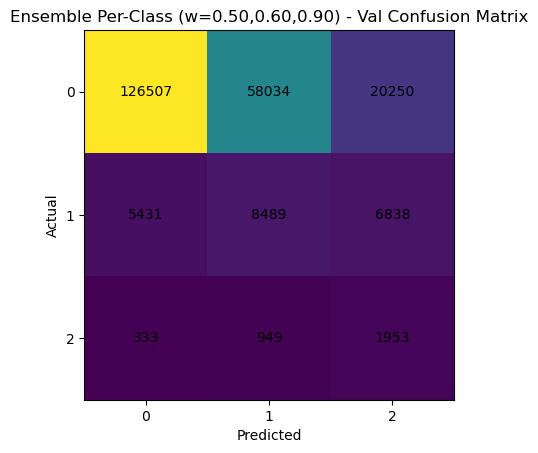


=== Ensemble Per-Class Two-Threshold - Test ===
Per-class recall [0,1,2]: [0.5917 0.3973 0.6573]
Macro recall: 0.5488
High-risk recall: 0.6573
High-risk precision: 0.0677

               precision    recall  f1-score   support

           0     0.9589    0.5917    0.7318    207818
           1     0.1184    0.3973    0.1825     21189
           2     0.0677    0.6573    0.1228      3411

    accuracy                         0.5749    232418
   macro avg     0.3817    0.5488    0.3457    232418
weighted avg     0.8692    0.5749    0.6728    232418



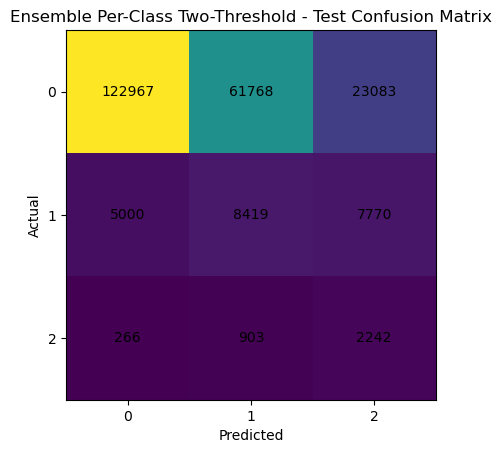

Predicted class-2 rate: 0.14239430680928328


In [12]:
# --- Evaluate per-class weighted ensemble on TEST ---
proba_val_pc = soft_vote_per_class(proba_val_cb, proba_val_lgbm, (best_w0, best_w1, best_w2))
pred_val_pc = apply_two_thresholds(proba_val_pc, best_tau1, best_tau2)
metrics_val_pc = eval_multiclass(y_val, pred_val_pc, name=f"Ensemble Per-Class (w={best_w0:.2f},{best_w1:.2f},{best_w2:.2f}) - Val")

proba_test_pc = soft_vote_per_class(proba_test_cb, proba_test_lgbm, (best_w0, best_w1, best_w2))
pred_test_pc = apply_two_thresholds(proba_test_pc, best_tau1, best_tau2)
metrics_test_pc = eval_multiclass(y_test, pred_test_pc, name=f"Ensemble Per-Class Two-Threshold - Test")
print("Predicted class-2 rate:", float((pred_test_pc==2).mean()))

## 4) Ensemble C — Stacking (meta model over base probabilities)

We train a **meta classifier** using the base models’ predicted probabilities as features:

\[
X_{meta} = [P_{CatBoost}(0),P_{CatBoost}(1),P_{CatBoost}(2),P_{LGBM}(0),P_{LGBM}(1),P_{LGBM}(2)]
\]

Then the meta model learns how to combine them (often better than a fixed weight).


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



=== Stacking Meta (LogReg) - Val ===
Per-class recall [0,1,2]: [0.7384 0.494  0.094 ]
Macro recall: 0.4421
High-risk recall: 0.094
High-risk precision: 0.0995

               precision    recall  f1-score   support

           0     0.9344    0.7384    0.8249    204791
           1     0.1605    0.4940    0.2422     20758
           2     0.0995    0.0940    0.0966      3235

    accuracy                         0.7071    228784
   macro avg     0.3981    0.4421    0.3879    228784
weighted avg     0.8524    0.7071    0.7617    228784



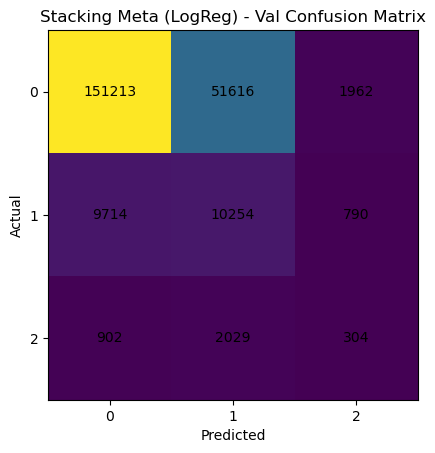


=== Stacking Meta (LogReg) - Test ===
Per-class recall [0,1,2]: [0.7155 0.5222 0.1328]
Macro recall: 0.4569
High-risk recall: 0.1328
High-risk precision: 0.1107

               precision    recall  f1-score   support

           0     0.9382    0.7155    0.8119    207818
           1     0.1584    0.5222    0.2431     21189
           2     0.1107    0.1328    0.1208      3411

    accuracy                         0.6894    232418
   macro avg     0.4025    0.4569    0.3919    232418
weighted avg     0.8550    0.6894    0.7499    232418



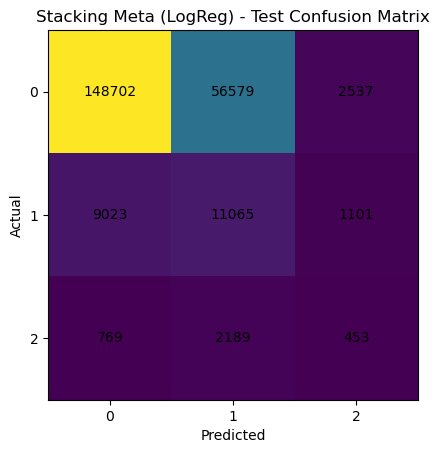

Chosen tau (Stacking Meta): 0.05

=== Stacking Meta Tuned (tau=0.05) - Test ===
Per-class recall [0,1,2]: [0.7084 0.4727 0.2577]
Macro recall: 0.4796
High-risk recall: 0.2577
High-risk precision: 0.0855

               precision    recall  f1-score   support

           0     0.9399    0.7084    0.8079    207818
           1     0.1529    0.4727    0.2310     21189
           2     0.0855    0.2577    0.1284      3411

    accuracy                         0.6803    232418
   macro avg     0.3928    0.4796    0.3891    232418
weighted avg     0.8556    0.6803    0.7453    232418



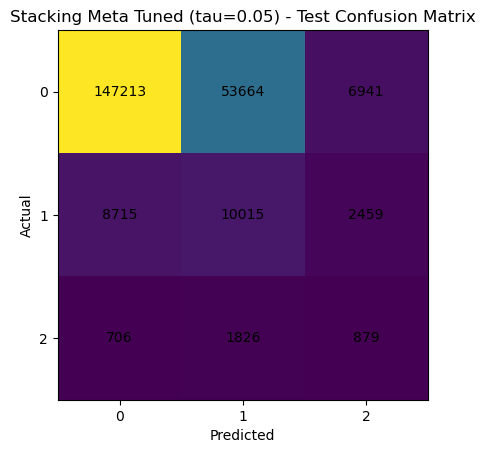

,tau,recall_high,precision_high,macro_recall
0,0.05,0.200618,0.078839,0.461327
1,0.10,0.163524,0.084640,0.455064
2,0.15,0.146213,0.090371,0.452337
3,0.20,0.132921,0.093478,0.449782
4,0.25,0.121484,0.096159,0.447573


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

def make_meta_X(p_cb, p_lgbm):
    return np.hstack([p_cb, p_lgbm])

Xmeta_train = make_meta_X(proba_train_cb, proba_train_lgbm)
Xmeta_val   = make_meta_X(proba_val_cb, proba_val_lgbm)
Xmeta_test  = make_meta_X(proba_test_cb, proba_test_lgbm)

# Meta model (multinomial logistic regression)
# - class_weight='balanced' helps the rare class 2
meta = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=2000,
        solver="lbfgs",
        multi_class="multinomial",
        class_weight="balanced",
        random_state=RANDOM_SEED
    ))
])

meta.fit(Xmeta_train, y_train)

pred_val_meta = meta.predict(Xmeta_val)
metrics_val_meta = eval_multiclass(y_val, pred_val_meta, name="Stacking Meta (LogReg) - Val")

# Predict proba for threshold tuning
proba_val_meta = meta.predict_proba(Xmeta_val)
proba_test_meta = meta.predict_proba(Xmeta_test)

pred_test_meta = np.argmax(proba_test_meta, axis=1)
metrics_test_meta = eval_multiclass(y_test, pred_test_meta, name="Stacking Meta (LogReg) - Test")

# Threshold tune on validation → apply on test
tau_meta, tau_df_meta = choose_tau_by_constraint(proba_val_meta, y_val, target_recall_high=0.80)
print("Chosen tau (Stacking Meta):", tau_meta)

pred_test_meta_tuned = apply_highrisk_threshold(proba_test_meta, tau_meta, class2_index=2)
metrics_test_meta_tuned = eval_multiclass(y_test, pred_test_meta_tuned, name=f"Stacking Meta Tuned (tau={tau_meta:.2f}) - Test")

tau_df_meta.head()


In [14]:
# ----------------------------
# Compare all ensemble variants on TEST
# ----------------------------
rows = [
    {"model": "Ensemble AVG Argmax", **metrics_test_avg},
    {"model": f"Ensemble AVG Two-Threshold (tau1={tau1_avg:.2f}, tau2={tau2_avg:.2f})", **metrics_test_avg_thr},
    {"model": f"Ensemble Per-Class Two-Threshold (w0={best_w0:.2f},w1={best_w1:.2f},w2={best_w2:.2f})", **metrics_test_pc},
    {"model": "Stacking Meta Argmax", **metrics_test_meta},
]
summary = pd.DataFrame(rows)[["model","macro_recall","recall_high","precision_high","recall_0","recall_1","recall_2"]]
summary = summary.sort_values(["macro_recall","recall_2","precision_high"], ascending=False)
summary


,model,macro_recall,recall_high,precision_high,recall_0,recall_1,recall_2
2,"Ensemble Per-Class Two-Threshold (w0=0.50,w1=0...",0.548773,0.657285,0.067744,0.591705,0.397329,0.657285
1,"Ensemble AVG Two-Threshold (tau1=0.30, tau2=0.17)",0.542677,0.652888,0.063798,0.572717,0.402426,0.652888
0,Ensemble AVG Argmax,0.486970,0.277924,0.129792,0.862110,0.320874,0.277924
3,Stacking Meta Argmax,0.456850,0.132806,0.110731,0.715540,0.522205,0.132806


In [17]:
# ----------------------------
# Save the best ensemble configuration (weights + tau + meta model)
# You can choose which one you prefer:
# - 'avg', 'weighted', or 'stacking'
# ----------------------------
# Pick the tuned ensemble you want to deploy:
deploy_choice = "per_class"

config = {
    "horizon": "3h",
    "target": "y_class",
    "class_definition": {"0":"0 collisions", "1":"1 collision", "2":"2+ collisions"},
    "base_models": {
        "catboost_model_path": str(CB_MODEL_PATH),
        "lightgbm_pipeline_path": str(LGBM_MODEL_PATH)
    },
    "deploy_choice": deploy_choice,
    "per_class_soft_voting": {
        "w_by_class": [float(best_w0), float(best_w1), float(best_w2)],
        "tau1": float(best_tau1),
        "tau2": float(best_tau2)
    }
}

# ----------------------------
# Save config + Test results (same pattern as other notebooks)
# ----------------------------


# 1) Save deploy config JSON
OUT_CFG = MODEL_DIR / "ensemble_deploy_config.json"
with open(OUT_CFG, "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)
print("Saved:", OUT_CFG)

# 2) Build a results table from metrics dicts you computed earlier
#    (Make sure these variables exist in your notebook.)
rows = []
if "metrics_test_avg" in globals():
    rows.append({"model": "Ensemble AVG Argmax (Test)", **metrics_test_avg})

if "metrics_test_avg_thr" in globals():
    rows.append({"model": f"Ensemble AVG Two-Threshold (tau1={tau1_avg:.2f}, tau2={tau2_avg:.2f}) - Test", **metrics_test_avg_thr})

# Per-class two-threshold (your chosen deploy_choice)
if "metrics_test_pc" in globals():
    rows.append({"model": f"Ensemble Per-Class Two-Threshold (w={best_w0:.2f},{best_w1:.2f},{best_w2:.2f}; tau1={best_tau1:.2f}, tau2={best_tau2:.2f}) - Test",
                 **metrics_test_pc})

# Stacking (optional)
if "metrics_test_meta" in globals():
    rows.append({"model": "Stacking Meta Argmax (Test)", **metrics_test_meta})

if "metrics_test_meta_thr" in globals():
    rows.append({"model": "Stacking Meta Two-Threshold (Test)", **metrics_test_meta_thr})

results_df = pd.DataFrame(rows)

OUT_CSV = MODEL_DIR / "ensemble_results_test.csv"
OUT_JSON = MODEL_DIR / "ensemble_results_test.json"

results_df.to_csv(OUT_CSV, index=False)
with open(OUT_JSON, "w", encoding="utf-8") as f:
    json.dump(rows, f, indent=2)

print("Saved:", OUT_CSV)
print("Saved:", OUT_JSON)

display(results_df.sort_values("macro_recall", ascending=False))


Saved: ../models/ensemble_deploy_config.json
Saved: ../models/ensemble_results_test.csv
Saved: ../models/ensemble_results_test.json


,model,recall_0,recall_1,recall_2,macro_recall,recall_high,precision_high
2,"Ensemble Per-Class Two-Threshold (w=0.50,0.60,...",0.591705,0.397329,0.657285,0.548773,0.657285,0.067744
1,"Ensemble AVG Two-Threshold (tau1=0.30, tau2=0....",0.572717,0.402426,0.652888,0.542677,0.652888,0.063798
0,Ensemble AVG Argmax (Test),0.862110,0.320874,0.277924,0.486970,0.277924,0.129792
3,Stacking Meta Argmax (Test),0.715540,0.522205,0.132806,0.456850,0.132806,0.110731
